<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-7-Three_Nonlinear_Hamiltonian%20Systems/Untitled190.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Double Pendulum**

**The Lagrangian formalism**

We consider the initial conditions:
$$\phi_1(0) = \pi/4, \qquad    \dot \phi_1(0) = 0,$$
$$\phi_2(0) = -\pi/4, \qquad   \dot \phi_2(0) = 0.$$
We also choose the double pendulum hyperparameters $$m_1=m_2=1,\qquad  l_1=l_2=1.$$

We consider the time horizon T=2. On such a short interval, the Runge--Kutta method is highly accurate, and we shall use this numerical solution as a benchmark for the PINN approximation. Since no closed-form solution is available for the double pendulum, the Runge--Kutta solution serves as a reliable reference trajectory.



Epoch 0: Total=177.017471, Physics=172.982773, Energy=4.034706
Epoch 500: Total=28.644871, Physics=25.539648, Energy=3.105223
Epoch 1000: Total=21.115519, Physics=18.319721, Energy=2.795798
Epoch 1500: Total=8.224642, Physics=6.160713, Energy=2.063929
Epoch 2000: Total=1.709326, Physics=1.549721, Energy=0.159605
Epoch 2500: Total=0.928934, Physics=0.698940, Energy=0.229994
Epoch 3000: Total=0.282792, Physics=0.275228, Energy=0.007563
Epoch 3500: Total=0.431274, Physics=0.262044, Energy=0.169230
Epoch 4000: Total=0.283077, Physics=0.204656, Energy=0.078421
Epoch 4500: Total=0.125099, Physics=0.118394, Energy=0.006705


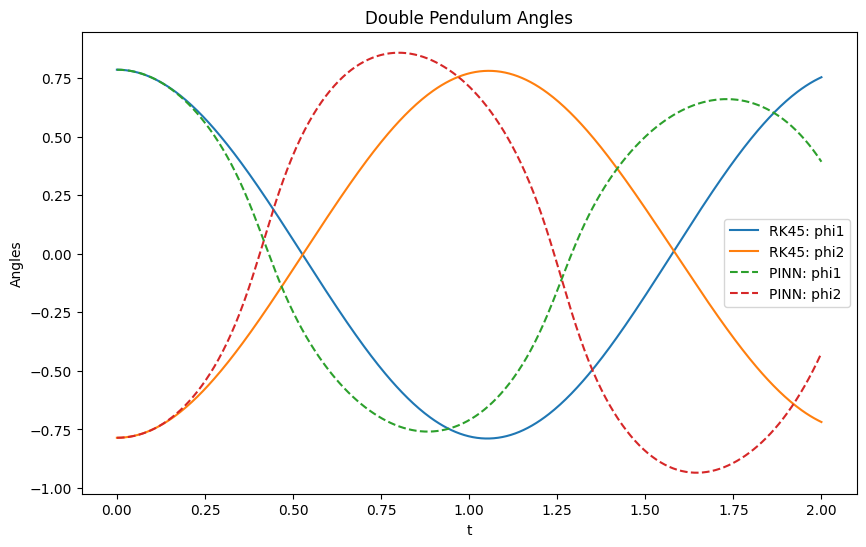

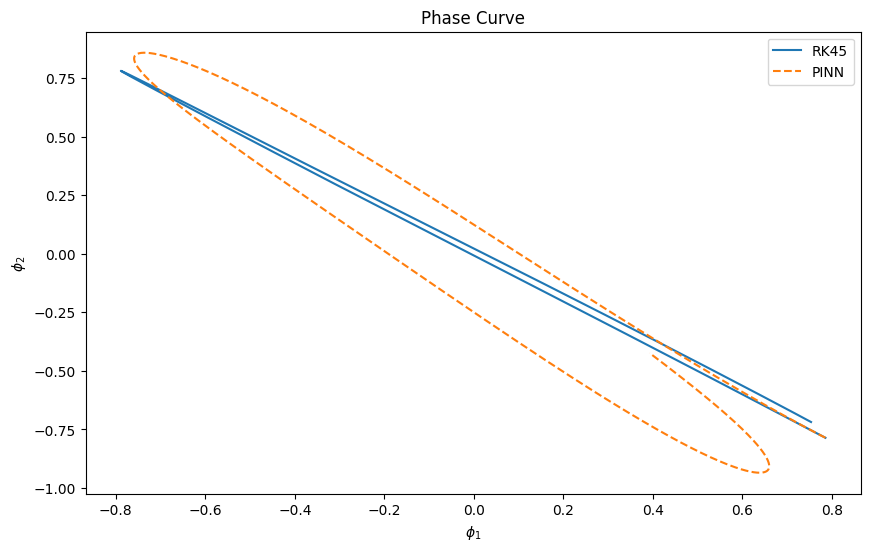

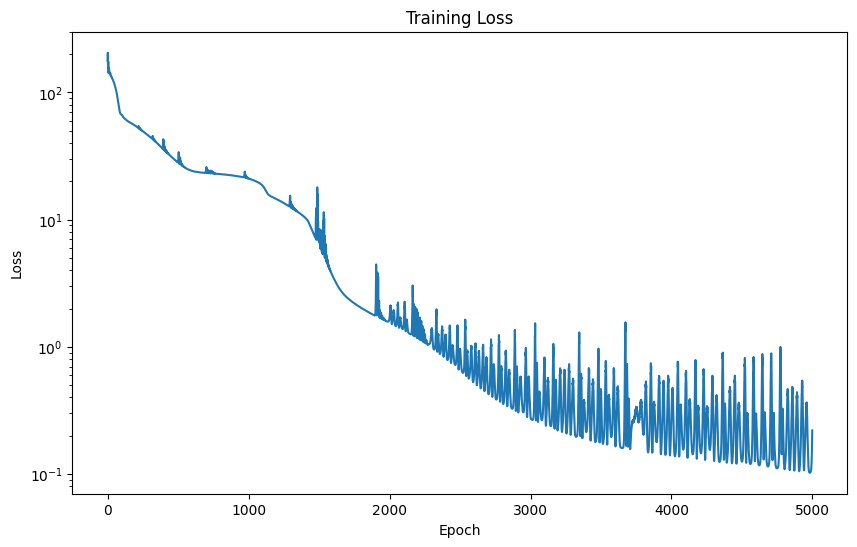

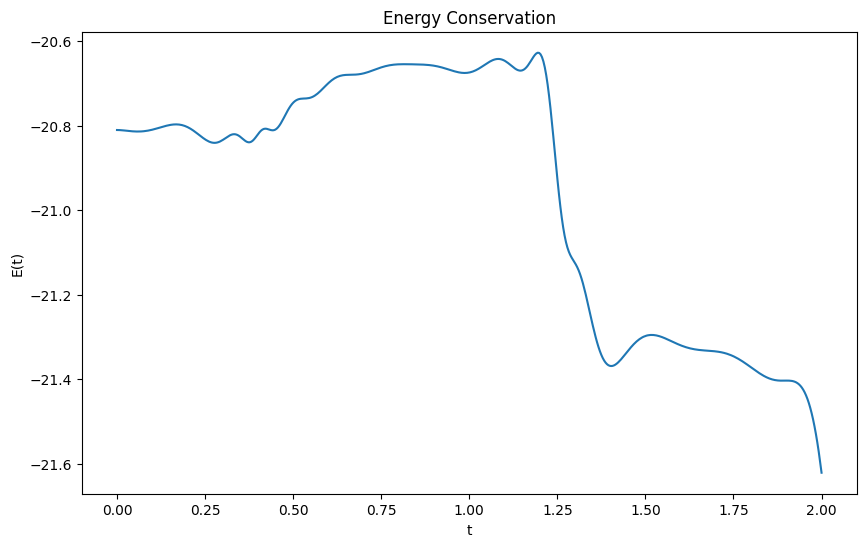

In [ ]:
# ============================================================
# Double Pendulum with PINNs
# Hard embedding of initial conditions
# Energy regularization
# TensorFlow / Keras implementation
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# Parameters
# ============================================================

g  = 9.81
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0

T = 2.0

# Initial conditions
phi1_0  = np.pi/4
dphi1_0 = 0.0

phi2_0  = -np.pi/4
dphi2_0 = 0.0

# ============================================================
# Exact solution via Runge-Kutta
# ============================================================

def double_pendulum_rhs(t, y):

    phi1, w1, phi2, w2 = y

    delta = phi1 - phi2

    den1 = (m1 + m2)*l1 - m2*l1*np.cos(delta)**2

    phi1_ddot = (
        m2*l1*w1**2*np.sin(delta)*np.cos(delta)
        + m2*g*np.sin(phi2)*np.cos(delta)
        + m2*l2*w2**2*np.sin(delta)
        - (m1+m2)*g*np.sin(phi1)
    ) / den1

    phi2_ddot = (
        -m2*l2*w2**2*np.sin(delta)*np.cos(delta)
        + (m1+m2)*(g*np.sin(phi1)*np.cos(delta)
        - l1*w1**2*np.sin(delta)
        - g*np.sin(phi2))
    ) / ((l2/l1)*den1)

    return [w1, phi1_ddot, w2, phi2_ddot]

t_eval = np.linspace(0, T, 500)

sol = solve_ivp(
    double_pendulum_rhs,
    [0, T],
    [phi1_0, dphi1_0, phi2_0, dphi2_0],
    t_eval=t_eval,
    method='RK45'
)

phi1_rk = sol.y[0]
phi2_rk = sol.y[2]

# ============================================================
# Neural Network
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(2)
])

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:, 0:1]
    N2 = NN[:, 1:2]

    phi1 = phi1_0 + dphi1_0*t + t**2 * N1
    phi2 = phi2_0 + dphi2_0*t + t**2 * N2

    return phi1, phi2

# ============================================================
# Energy
# ============================================================

def energy(phi1, phi2, dphi1, dphi2):

    K = (
        0.5*(m1+m2)*l1**2*dphi1**2
        + 0.5*m2*l2**2*dphi2**2
        + m2*l1*l2*dphi1*dphi2*tf.cos(phi1 - phi2)
    )

    V = (
        -(m1+m2)*g*l1*tf.cos(phi1)
        - m2*g*l2*tf.cos(phi2)
    )

    return K + V

E0 = (
    -(m1+m2)*g*l1*np.cos(phi1_0)
    - m2*g*l2*np.cos(phi2_0)
)

# ============================================================
# Loss function
# ============================================================

lambda_energy = 1.0

@tf.function
def compute_loss(t):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(t)

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch(t)

            phi1, phi2 = pinn_solution(t)

        dphi1 = tape1.gradient(phi1, t)
        dphi2 = tape1.gradient(phi2, t)

    ddphi1 = tape2.gradient(dphi1, t)
    ddphi2 = tape2.gradient(dphi2, t)

    delta = phi1 - phi2

    # Residuals
    R1 = (
        (m1+m2)*l1**2*ddphi1
        + m2*l1*l2*ddphi2*tf.cos(delta)
        + m2*l1*l2*dphi2**2*tf.sin(delta)
        + (m1+m2)*g*l1*tf.sin(phi1)
    )

    R2 = (
        m2*l2**2*ddphi2
        + m2*l1*l2*ddphi1*tf.cos(delta)
        - m2*l1*l2*dphi1**2*tf.sin(delta)
        + m2*g*l2*tf.sin(phi2)
    )

    physics_loss = tf.reduce_mean(R1**2 + R2**2)

    # Energy conservation
    E = energy(phi1, phi2, dphi1, dphi2)

    energy_loss = tf.reduce_mean((E - E0)**2)

    total_loss = physics_loss + lambda_energy*energy_loss

    return total_loss, physics_loss, energy_loss

# ============================================================
# Training
# ============================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

epochs = 5000

loss_history = []

t_train = tf.convert_to_tensor(
    np.linspace(0, T, 200).reshape(-1,1),
    dtype=tf.float32
)

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        total_loss, phys_loss, energy_loss = compute_loss(t_train)

    grads = tape.gradient(total_loss, model.trainable_variables)

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    loss_history.append(total_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch}: "
            f"Total={total_loss.numpy():.6f}, "
            f"Physics={phys_loss.numpy():.6f}, "
            f"Energy={energy_loss.numpy():.6f}"
        )

# ============================================================
# Predictions
# ============================================================

t_test = tf.convert_to_tensor(
    t_eval.reshape(-1,1),
    dtype=tf.float32
)

with tf.GradientTape(persistent=True) as tape2:

    tape2.watch(t_test)

    with tf.GradientTape(persistent=True) as tape1:

        tape1.watch(t_test)

        phi1_pinn, phi2_pinn = pinn_solution(t_test)

    dphi1_pinn = tape1.gradient(phi1_pinn, t_test)
    dphi2_pinn = tape1.gradient(phi2_pinn, t_test)

E_pinn = energy(
    phi1_pinn,
    phi2_pinn,
    dphi1_pinn,
    dphi2_pinn
)

phi1_pinn = phi1_pinn.numpy().flatten()
phi2_pinn = phi2_pinn.numpy().flatten()

E_pinn = E_pinn.numpy().flatten()

# ============================================================
# Plot 1: Angles versus time
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(t_eval, phi1_rk, label='RK45: phi1')
plt.plot(t_eval, phi2_rk, label='RK45: phi2')

plt.plot(t_eval, phi1_pinn, '--', label='PINN: phi1')
plt.plot(t_eval, phi2_pinn, '--', label='PINN: phi2')

plt.xlabel('t')
plt.ylabel('Angles')
plt.legend()
plt.title('Double Pendulum Angles')

plt.show()

# ============================================================
# Plot 2: Parametric plot
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(phi1_rk, phi2_rk, label='RK45')
plt.plot(phi1_pinn, phi2_pinn, '--', label='PINN')

plt.xlabel(r'$\phi_1$')
plt.ylabel(r'$\phi_2$')

plt.legend()
plt.title('Phase Curve')

plt.show()

# ============================================================
# Plot 3: Loss versus epochs
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training Loss')

plt.show()

# ============================================================
# Plot 4: Energy
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(t_eval, E_pinn)

plt.xlabel('t')
plt.ylabel('E(t)')

plt.title('Energy Conservation')

plt.show()

**Improved architecture**

To improve the quality and stability of the approximation, we modify the architecture in several significant ways.




(i) First we remove  the energy conservation regularizer, leaving more freedom for the network to learn.



(ii) Then we reformulate the system from two second-order differential equations into four first-order equations. This avoids the direct computation of second derivatives, which are typically less stable in PINN implementations and often lead to significant numerical errors during training.


(iii) The tanh-activated network appears to underfit the oscillatory behavior of the solution, exhibiting a low-frequency spectral bias. To alleviate this issue, we introduce a Fourier feature layer as the first layer of the network:
\[
t \mapsto
\bigl(
t,\,
\sin(kt),\,
\cos(kt)
\bigr),
\]
using the frequencies \(k=1,2\). This enriches the representation space with oscillatory components and improves the network's ability to capture periodic dynamics.


(iv) We replace the standard tanh activations by Sinusoidal Representation Network (SIREN) activations. In such a layer, the activation is computed as
\[
\sin\bigl(\omega(Wx+b)\bigr),
\]
instead of the classical
\[
\tanh(Wx+b),
\]
where \(W\) and \(b\) denote the trainable weights and biases, while \(\omega\) is a frequency parameter. In our implementation we consider values \(\omega=1,2,3\). SIREN activations are naturally adapted to oscillatory problems and generally provide better approximations for wave-like and Hamiltonian dynamics.


(v) Finally, in order to improve the accuracy of the optimization process, we augment the Adam training stage with an L-BFGS optimization step.




<>:444: SyntaxWarning: invalid escape sequence '\p'
<>:451: SyntaxWarning: invalid escape sequence '\p'
<>:459: SyntaxWarning: invalid escape sequence '\p'
<>:467: SyntaxWarning: invalid escape sequence '\p'
<>:509: SyntaxWarning: invalid escape sequence '\p'
<>:444: SyntaxWarning: invalid escape sequence '\p'
<>:451: SyntaxWarning: invalid escape sequence '\p'
<>:459: SyntaxWarning: invalid escape sequence '\p'
<>:467: SyntaxWarning: invalid escape sequence '\p'
<>:509: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2218/4230512957.py:444: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_1$'
/tmp/ipykernel_2218/4230512957.py:451: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_2$'
/tmp/ipykernel_2218/4230512957.py:459: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_1$'
/tmp/ipykernel_2218/4230512957.py:467: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_2$'
/tmp/ipykernel_2218/4230512957.py:509: SyntaxWar

Epoch 0, Loss = 191.72337341
Epoch 1000, Loss = 0.85936373
Epoch 2000, Loss = 0.07961542
Epoch 3000, Loss = 0.02323483
Epoch 4000, Loss = 0.00870389
Starting L-BFGS...


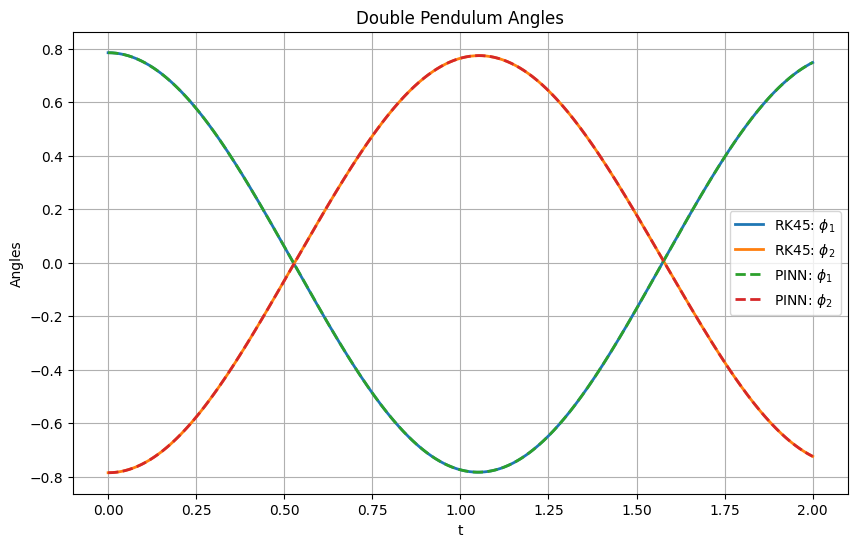

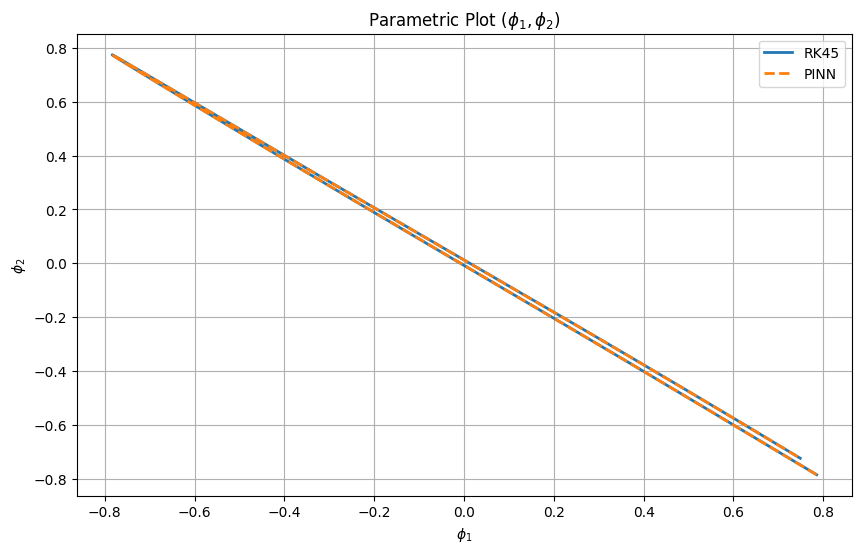

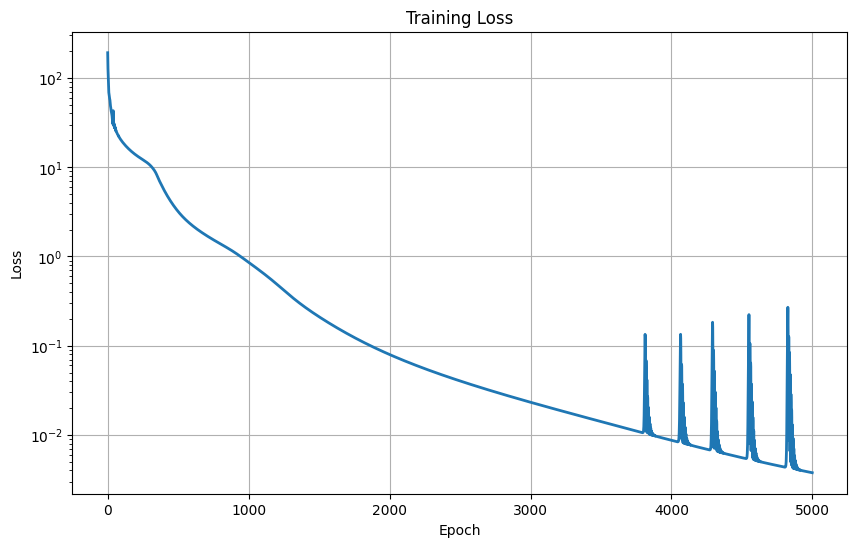

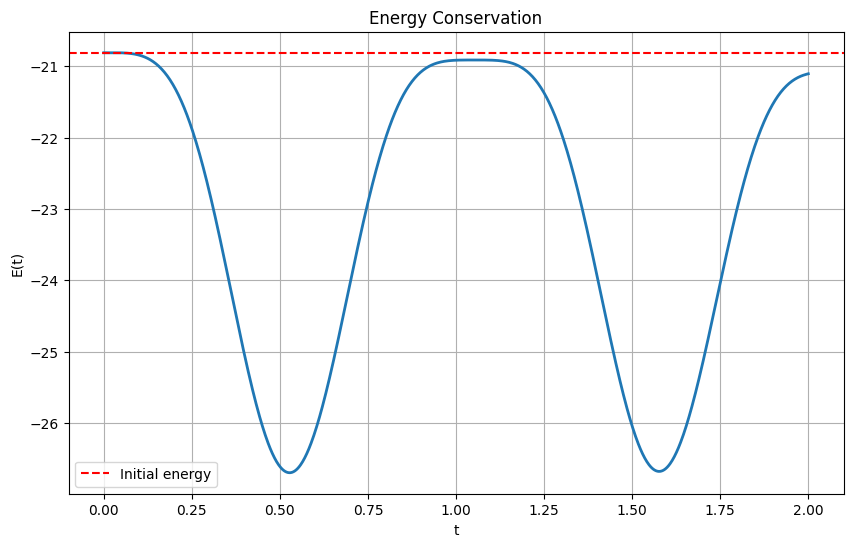

In [ ]:
# ============================================================
# Advanced PINN for the Double Pendulum
#
# Improvements:
# 1. First-order formulation
# 2. Fourier feature layer
# 3. SIREN activations
# 4. Nondimensionalized equations
# 5. Adam + L-BFGS optimization
# 6. Long training
#
# TensorFlow / Keras implementation
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# ============================================================
# Parameters
# ============================================================

g  = 9.81
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0

T = 2.0

# ============================================================
# Nondimensionalization
#
# tau = sqrt(g/l1) t
#
# Since l1=1:
# tau = sqrt(g) t
# ============================================================

scale_t = np.sqrt(g/l1)

# ============================================================
# Initial conditions
# ============================================================

phi1_0 = np.pi/4
w1_0   = 0.0

phi2_0 = -np.pi/4
w2_0   = 0.0

# ============================================================
# Reference RK45 solution
# ============================================================

def rhs(t, y):

    phi1, w1, phi2, w2 = y

    delta = phi1 - phi2

    den1 = (m1+m2)*l1 - m2*l1*np.cos(delta)**2

    phi1_ddot = (
        m2*l1*w1**2*np.sin(delta)*np.cos(delta)
        + m2*g*np.sin(phi2)*np.cos(delta)
        + m2*l2*w2**2*np.sin(delta)
        - (m1+m2)*g*np.sin(phi1)
    ) / den1

    phi2_ddot = (
        -m2*l2*w2**2*np.sin(delta)*np.cos(delta)
        + (m1+m2)*(g*np.sin(phi1)*np.cos(delta)
        - l1*w1**2*np.sin(delta)
        - g*np.sin(phi2))
    ) / ((l2/l1)*den1)

    return [w1, phi1_ddot, w2, phi2_ddot]

t_eval = np.linspace(0, T, 1000)

sol = solve_ivp(
    rhs,
    [0, T],
    [phi1_0, w1_0, phi2_0, w2_0],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-10
)

phi1_rk = sol.y[0]
phi2_rk = sol.y[2]

# ============================================================
# Fourier Features
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def __init__(self, K=3):
        super().__init__()
        self.K = K

    def call(self, t):

        features = [t]

        for k in range(1, self.K+1):

            features.append(tf.sin(k*t))
            features.append(tf.cos(k*t))

        return tf.concat(features, axis=1)

# ============================================================
# SIREN Layer
# ============================================================

class SineLayer(tf.keras.layers.Layer):

    def __init__(self, units, omega_0=2.0):
        super().__init__()

        self.units = units
        self.omega_0 = omega_0

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):

        return tf.sin(
            self.omega_0 * (tf.matmul(inputs, self.W) + self.b)
        )

# ============================================================
# Neural Network
#
# Outputs:
# phi1, w1, phi2, w2
# ============================================================

inputs = tf.keras.Input(shape=(1,))

x = FourierLayer(K=3)(inputs)

x = SineLayer(128)(x)
x = SineLayer(128)(x)
x = SineLayer(128)(x)

outputs = tf.keras.layers.Dense(4)(x)

model = tf.keras.Model(inputs, outputs)

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:,0:1]
    N2 = NN[:,1:2]
    N3 = NN[:,2:3]
    N4 = NN[:,3:4]

    phi1 = phi1_0 + t*w1_0 + t**2*N1
    w1   = w1_0 + t*N2

    phi2 = phi2_0 + t*w2_0 + t**2*N3
    w2   = w2_0 + t*N4

    return phi1, w1, phi2, w2

# ============================================================
# Energy
# ============================================================

def energy(phi1, w1, phi2, w2):

    K = (
        0.5*(m1+m2)*l1**2*w1**2
        + 0.5*m2*l2**2*w2**2
        + m2*l1*l2*w1*w2*tf.cos(phi1-phi2)
    )

    V = (
        -(m1+m2)*g*l1*tf.cos(phi1)
        - m2*g*l2*tf.cos(phi2)
    )

    return K + V

E0 = (
    -(m1+m2)*g*l1*np.cos(phi1_0)
    - m2*g*l2*np.cos(phi2_0)
)

# ============================================================
# Loss
# ============================================================

lambda_energy = 0.0

@tf.function
def compute_loss(t):

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(t)

        phi1, w1, phi2, w2 = pinn_solution(t)

    dphi1 = tape.gradient(phi1, t)
    dw1   = tape.gradient(w1, t)

    dphi2 = tape.gradient(phi2, t)
    dw2   = tape.gradient(w2, t)

    delta = phi1 - phi2

    den1 = (m1+m2)*l1 - m2*l1*tf.cos(delta)**2

    phi1_ddot = (
        m2*l1*w1**2*tf.sin(delta)*tf.cos(delta)
        + m2*g*tf.sin(phi2)*tf.cos(delta)
        + m2*l2*w2**2*tf.sin(delta)
        - (m1+m2)*g*tf.sin(phi1)
    ) / den1

    phi2_ddot = (
        -m2*l2*w2**2*tf.sin(delta)*tf.cos(delta)
        + (m1+m2)*(g*tf.sin(phi1)*tf.cos(delta)
        - l1*w1**2*tf.sin(delta)
        - g*tf.sin(phi2))
    ) / ((l2/l1)*den1)

    # ========================================================
    # First-order residuals
    # ========================================================

    R1 = dphi1 - w1
    R2 = dw1   - phi1_ddot

    R3 = dphi2 - w2
    R4 = dw2   - phi2_ddot

    physics_loss = tf.reduce_mean(
        R1**2 + R2**2 + R3**2 + R4**2
    )

    # ========================================================
    # Energy regularization
    # ========================================================

    E = energy(phi1, w1, phi2, w2)

    energy_loss = tf.reduce_mean((E-E0)**2)

    total_loss = physics_loss + lambda_energy*energy_loss

    return total_loss

# ============================================================
# Adam training
# ============================================================

optimizer = tf.keras.optimizers.Adam(1e-4)

epochs = 5000

loss_history = []

t_train = tf.convert_to_tensor(
    np.linspace(0, T, 500).reshape(-1,1),
    dtype=tf.float32
)

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        loss = compute_loss(t_train)

    grads = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    loss_history.append(loss.numpy())

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch}, Loss = {loss.numpy():.8f}"
        )

# ============================================================
# L-BFGS optimization
# ============================================================

vars = model.trainable_variables

shapes = [v.shape for v in vars]
sizes  = [tf.size(v).numpy() for v in vars]

def pack_weights():

    return tf.concat(
        [tf.reshape(v, [-1]) for v in vars],
        axis=0
    )

def unpack_weights(w):

    idx = 0

    for v, shape, size in zip(vars, shapes, sizes):

        new_val = tf.reshape(
            w[idx:idx+size],
            shape
        )

        v.assign(new_val)

        idx += size

def loss_and_grad(w):

    unpack_weights(w)

    with tf.GradientTape() as tape:

        loss = compute_loss(t_train)

    grads = tape.gradient(loss, vars)

    grad_flat = tf.concat(
        [tf.reshape(g, [-1]) for g in grads],
        axis=0
    )

    return (
        loss.numpy().astype(np.float64),
        grad_flat.numpy().astype(np.float64)
    )

print("Starting L-BFGS...")

result = minimize(
    fun=loss_and_grad,
    x0=pack_weights().numpy(),
    jac=True,
    method='L-BFGS-B',
    options={
        'maxiter': 5000,
        'maxcor': 50,
        'ftol': 1e-12
    }
)

unpack_weights(result.x)



# ============================================================
# Predictions
# ============================================================

t_test = tf.convert_to_tensor(
    t_eval.reshape(-1,1),
    dtype=tf.float32
)

phi1_pinn, w1_pinn, phi2_pinn, w2_pinn = pinn_solution(t_test)

# ============================================================
# Convert everything consistently to NumPy
# ============================================================

phi1_pinn = phi1_pinn.numpy().flatten()
phi2_pinn = phi2_pinn.numpy().flatten()

w1_pinn = w1_pinn.numpy().flatten()
w2_pinn = w2_pinn.numpy().flatten()

# ============================================================
# Correct energy computation
# ============================================================

E_pinn = (

    0.5*(m1+m2)*l1**2*w1_pinn**2

    +

    0.5*m2*l2**2*w2_pinn**2

    +

    m2*l1*l2*w1_pinn*w2_pinn
    * np.cos(phi1_pinn-phi2_pinn)

    -

    (m1+m2)*g*l1*np.cos(phi1_pinn)

    -

    m2*g*l2*np.cos(phi2_pinn)

)
# ============================================================
# Plot 1:
# Angles versus time
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    phi1_rk,
    linewidth=2,
    label='RK45: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_rk,
    linewidth=2,
    label='RK45: $\phi_2$'
)

plt.plot(
    t_eval,
    phi1_pinn,
    '--',
    linewidth=2,
    label='PINN: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_pinn,
    '--',
    linewidth=2,
    label='PINN: $\phi_2$'
)

plt.xlabel('t')
plt.ylabel('Angles')

plt.title(
    'Double Pendulum Angles'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 2:
# Parametric plot
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    phi1_rk,
    phi2_rk,
    linewidth=2,
    label='RK45'
)

plt.plot(
    phi1_pinn,
    phi2_pinn,
    '--',
    linewidth=2,
    label='PINN'
)

plt.xlabel(r'$\phi_1$')
plt.ylabel(r'$\phi_2$')

plt.title(
    'Parametric Plot $(\phi_1,\phi_2)$'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 3:
# Loss versus epochs
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    loss_history,
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training Loss'
)

plt.grid()

plt.show()
# ============================================================
# Plot 4
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    E_pinn,
    linewidth=2
)

plt.axhline(
    E0,
    color='red',
    linestyle='--',
    label='Initial energy'
)

plt.xlabel('t')
plt.ylabel('E(t)')

plt.title('Energy Conservation')

plt.legend()

plt.grid()

plt.show()









**The long-run regime:** Consider T=10.

<>:588: SyntaxWarning: invalid escape sequence '\p'
<>:595: SyntaxWarning: invalid escape sequence '\p'
<>:603: SyntaxWarning: invalid escape sequence '\p'
<>:611: SyntaxWarning: invalid escape sequence '\p'
<>:653: SyntaxWarning: invalid escape sequence '\p'
<>:588: SyntaxWarning: invalid escape sequence '\p'
<>:595: SyntaxWarning: invalid escape sequence '\p'
<>:603: SyntaxWarning: invalid escape sequence '\p'
<>:611: SyntaxWarning: invalid escape sequence '\p'
<>:653: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2015/3937701836.py:588: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_1$'
/tmp/ipykernel_2015/3937701836.py:595: SyntaxWarning: invalid escape sequence '\p'
  label='RK45: $\phi_2$'
/tmp/ipykernel_2015/3937701836.py:603: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_1$'
/tmp/ipykernel_2015/3937701836.py:611: SyntaxWarning: invalid escape sequence '\p'
  label='PINN: $\phi_2$'
/tmp/ipykernel_2015/3937701836.py:653: SyntaxWar

Epoch 0, Loss = 2569088.5000000000
Epoch 1000, Loss = 3770.1269531250
Epoch 2000, Loss = 1358.1903076172
Epoch 3000, Loss = 659.0507812500
Epoch 4000, Loss = 380.9662475586

Starting L-BFGS optimization...


L-BFGS completed.



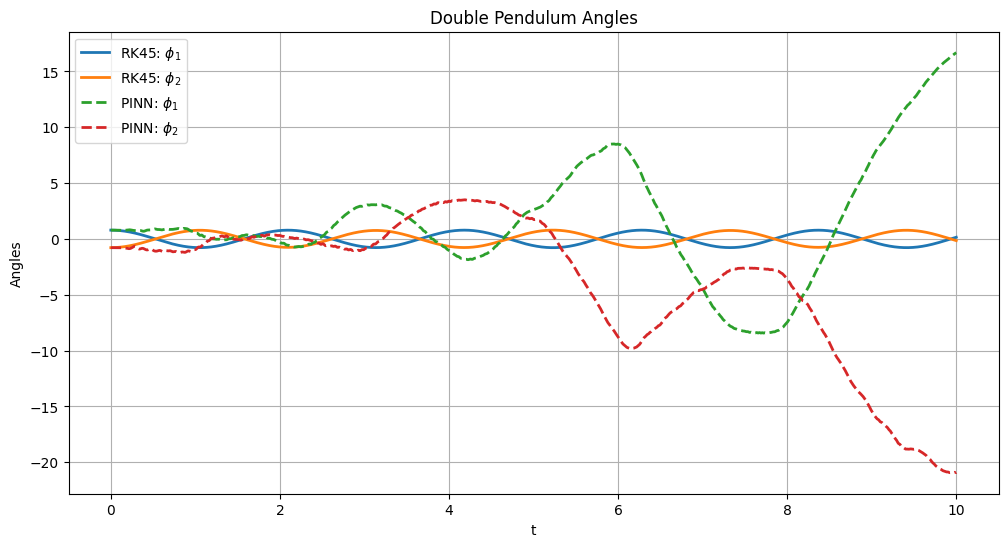

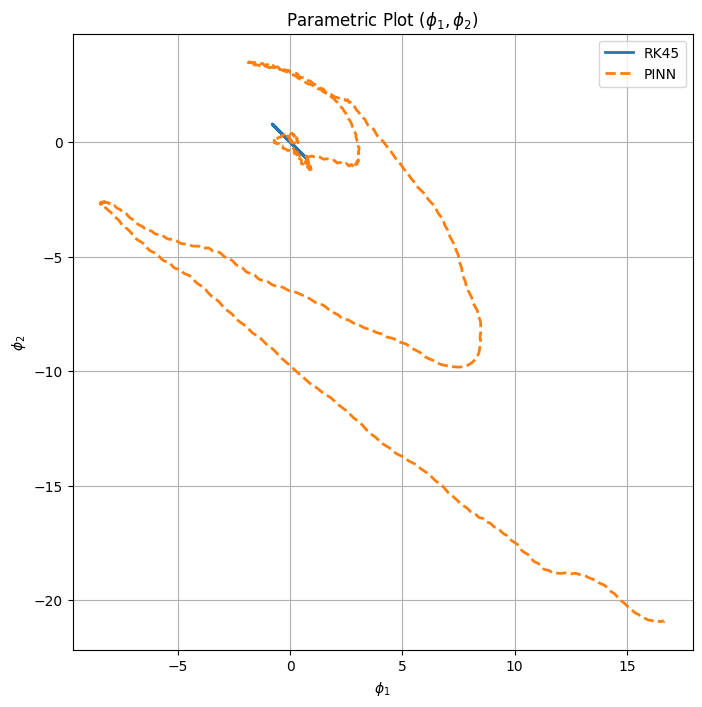

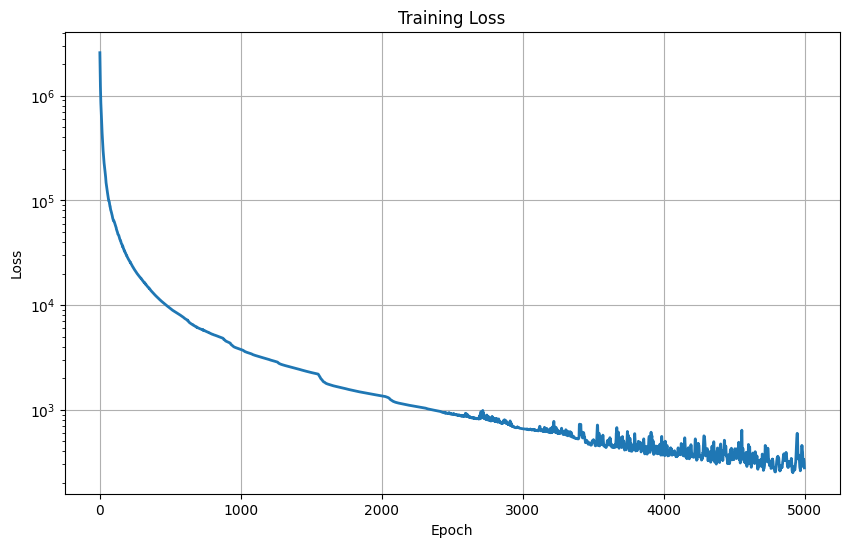

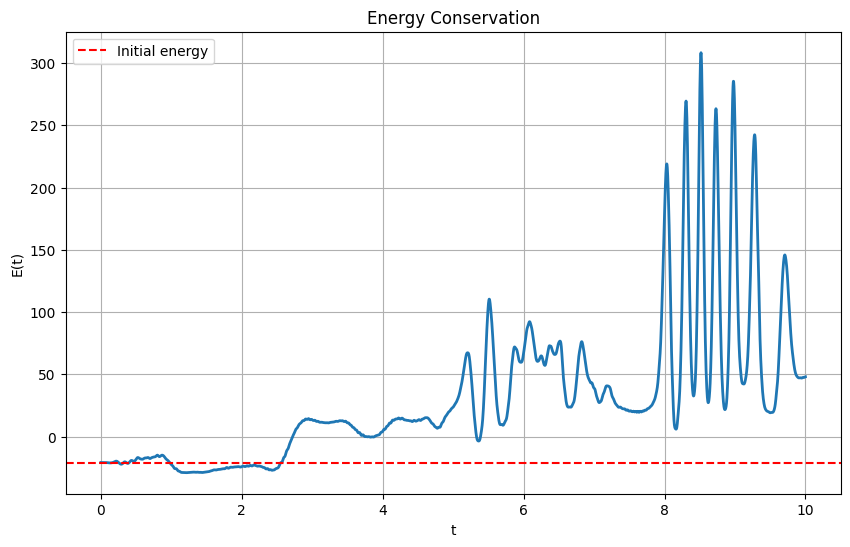

In [ ]:
# ============================================================
# Advanced PINN for the Double Pendulum
#
# Long-time simulation on [0,10]
#
# Features:
# 1. First-order formulation
# 2. Fourier feature layer
# 3. SIREN activations
# 4. Energy regularization
# 5. Adam + L-BFGS optimization
# 6. RK45 comparison
#
# TensorFlow / Keras implementation
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# ============================================================
# Parameters
# ============================================================

g  = 9.81

m1 = 1.0
m2 = 1.0

l1 = 1.0
l2 = 1.0

T = 10.0

# ============================================================
# Initial conditions
# ============================================================

phi1_0 = np.pi/4
w1_0   = 0.0

phi2_0 = -np.pi/4
w2_0   = 0.0

# ============================================================
# RK45 reference solution
# ============================================================

def rhs(t, y):

    phi1, w1, phi2, w2 = y

    delta = phi1 - phi2

    den1 = (
        (m1+m2)*l1
        -
        m2*l1*np.cos(delta)**2
    )

    phi1_ddot = (

        m2*l1*w1**2*np.sin(delta)*np.cos(delta)

        +

        m2*g*np.sin(phi2)*np.cos(delta)

        +

        m2*l2*w2**2*np.sin(delta)

        -

        (m1+m2)*g*np.sin(phi1)

    ) / den1

    phi2_ddot = (

        -m2*l2*w2**2*np.sin(delta)*np.cos(delta)

        +

        (m1+m2)*(
            g*np.sin(phi1)*np.cos(delta)
            -
            l1*w1**2*np.sin(delta)
            -
            g*np.sin(phi2)
        )

    ) / ((l2/l1)*den1)

    return [
        w1,
        phi1_ddot,
        w2,
        phi2_ddot
    ]

# ============================================================
# RK evaluation points
# ============================================================

t_eval = np.linspace(0, T, 5000)

sol = solve_ivp(

    rhs,

    [0, T],

    [
        phi1_0,
        w1_0,
        phi2_0,
        w2_0
    ],

    t_eval=t_eval,

    rtol=1e-10,
    atol=1e-10

)

phi1_rk = sol.y[0]
phi2_rk = sol.y[2]

# ============================================================
# Fourier Layer
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def __init__(self, K=5):

        super().__init__()

        self.K = K

    def call(self, t):

        features = [t]

        for k in range(1, self.K+1):

            features.append(tf.sin(k*t))
            features.append(tf.cos(k*t))

        return tf.concat(features, axis=1)

# ============================================================
# SIREN Layer
# ============================================================

class SineLayer(tf.keras.layers.Layer):

    def __init__(self, units, omega_0=5.0):

        super().__init__()

        self.units = units
        self.omega_0 = omega_0

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):

        return tf.sin(
            self.omega_0 *
            (tf.matmul(inputs, self.W) + self.b)
        )

# ============================================================
# Neural Network
# ============================================================

inputs = tf.keras.Input(shape=(1,))

x = FourierLayer(K=3)(inputs)

x = SineLayer(128, omega_0=5.0)(x)
x = SineLayer(128, omega_0=5.0)(x)
x = SineLayer(128, omega_0=5.0)(x)

outputs = tf.keras.layers.Dense(4)(x)

model = tf.keras.Model(inputs, outputs)

# ============================================================
# Hard embedding
# ============================================================

def pinn_solution(t):

    NN = model(t)

    N1 = NN[:,0:1]
    N2 = NN[:,1:2]

    N3 = NN[:,2:3]
    N4 = NN[:,3:4]

    phi1 = (
        phi1_0
        +
        t*w1_0
        +
        t**2*N1
    )

    w1 = (
        w1_0
        +
        t*N2
    )

    phi2 = (
        phi2_0
        +
        t*w2_0
        +
        t**2*N3
    )

    w2 = (
        w2_0
        +
        t*N4
    )

    return phi1, w1, phi2, w2

# ============================================================
# Energy
# ============================================================

def energy(phi1, w1, phi2, w2):

    kinetic = (

        0.5*(m1+m2)*l1**2*w1**2

        +

        0.5*m2*l2**2*w2**2

        +

        m2*l1*l2*w1*w2
        * tf.cos(phi1-phi2)

    )

    potential = (

        -(m1+m2)*g*l1*tf.cos(phi1)

        -

        m2*g*l2*tf.cos(phi2)

    )

    return kinetic + potential

E0 = (

    -(m1+m2)*g*l1*np.cos(phi1_0)

    -

    m2*g*l2*np.cos(phi2_0)

)

# ============================================================
# Energy regularization weight
# ============================================================

lambda_energy = 1e-3

# ============================================================
# Loss function
# ============================================================

@tf.function
def compute_loss(t):

    with tf.GradientTape(persistent=True) as tape:

        tape.watch(t)

        phi1, w1, phi2, w2 = pinn_solution(t)

    dphi1 = tape.gradient(phi1, t)
    dw1   = tape.gradient(w1, t)

    dphi2 = tape.gradient(phi2, t)
    dw2   = tape.gradient(w2, t)

    delta = phi1 - phi2

    den1 = (
        (m1+m2)*l1
        -
        m2*l1*tf.cos(delta)**2
    )

    phi1_ddot = (

        m2*l1*w1**2*tf.sin(delta)*tf.cos(delta)

        +

        m2*g*tf.sin(phi2)*tf.cos(delta)

        +

        m2*l2*w2**2*tf.sin(delta)

        -

        (m1+m2)*g*tf.sin(phi1)

    ) / den1

    phi2_ddot = (

        -m2*l2*w2**2*tf.sin(delta)*tf.cos(delta)

        +

        (m1+m2)*(
            g*tf.sin(phi1)*tf.cos(delta)
            -
            l1*w1**2*tf.sin(delta)
            -
            g*tf.sin(phi2)
        )

    ) / ((l2/l1)*den1)

    # ========================================================
    # Residuals
    # ========================================================

    R1 = dphi1 - w1
    R2 = dw1   - phi1_ddot

    R3 = dphi2 - w2
    R4 = dw2   - phi2_ddot

    physics_loss = tf.reduce_mean(
        R1**2 + R2**2 + R3**2 + R4**2
    )

    # ========================================================
    # Energy regularization
    # ========================================================

    E = energy(phi1, w1, phi2, w2)

    energy_loss = tf.reduce_mean(
        (E-E0)**2
    )

    total_loss = (
        physics_loss
        +
        lambda_energy*energy_loss
    )

    return total_loss

# ============================================================
# Adam optimizer
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    5e-5
)

epochs = 5000

loss_history = []

# ============================================================
# Training points
# ============================================================

t_train = tf.convert_to_tensor(

    np.linspace(0, T, 4000).reshape(-1,1),

    dtype=tf.float32

)

# ============================================================
# Adam training
# ============================================================

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        loss = compute_loss(t_train)

    grads = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    loss_history.append(loss.numpy())

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch}, Loss = {loss.numpy():.10f}"
        )

# ============================================================
# L-BFGS optimization
# ============================================================

vars = model.trainable_variables

shapes = [v.shape for v in vars]
sizes  = [tf.size(v).numpy() for v in vars]

# ============================================================
# Pack weights
# ============================================================

def pack_weights():

    return tf.concat(
        [tf.reshape(v, [-1]) for v in vars],
        axis=0
    )

# ============================================================
# Unpack weights
# ============================================================

def unpack_weights(w):

    idx = 0

    for v, shape, size in zip(vars, shapes, sizes):

        new_val = tf.reshape(
            w[idx:idx+size],
            shape
        )

        v.assign(new_val)

        idx += size

# ============================================================
# Loss and gradients
# ============================================================

def loss_and_grad(w):

    unpack_weights(w)

    with tf.GradientTape() as tape:

        loss = compute_loss(t_train)

    grads = tape.gradient(loss, vars)

    grad_flat = tf.concat(
        [tf.reshape(g, [-1]) for g in grads],
        axis=0
    )

    return (
        loss.numpy().astype(np.float64),
        grad_flat.numpy().astype(np.float64)
    )

print("\nStarting L-BFGS optimization...\n")

result = minimize(

    fun=loss_and_grad,

    x0=pack_weights().numpy(),

    jac=True,

    method='L-BFGS-B',

    options={

        'maxiter': 15000,
        'maxcor': 50,
        'ftol': 1e-12

    }

)

unpack_weights(result.x)

print("\nL-BFGS completed.\n")

# ============================================================
# Predictions
# ============================================================

t_test = tf.convert_to_tensor(
    t_eval.reshape(-1,1),
    dtype=tf.float32
)

phi1_pinn, w1_pinn, phi2_pinn, w2_pinn = pinn_solution(t_test)

phi1_pinn = phi1_pinn.numpy().flatten()
phi2_pinn = phi2_pinn.numpy().flatten()

w1_pinn = w1_pinn.numpy().flatten()
w2_pinn = w2_pinn.numpy().flatten()

# ============================================================
# Energy
# ============================================================

E_pinn = (

    0.5*(m1+m2)*l1**2*w1_pinn**2

    +

    0.5*m2*l2**2*w2_pinn**2

    +

    m2*l1*l2*w1_pinn*w2_pinn
    * np.cos(phi1_pinn-phi2_pinn)

    -

    (m1+m2)*g*l1*np.cos(phi1_pinn)

    -

    m2*g*l2*np.cos(phi2_pinn)

)

# ============================================================
# Plot 1:
# Angles versus time
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    t_eval,
    phi1_rk,
    linewidth=2,
    label='RK45: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_rk,
    linewidth=2,
    label='RK45: $\phi_2$'
)

plt.plot(
    t_eval,
    phi1_pinn,
    '--',
    linewidth=2,
    label='PINN: $\phi_1$'
)

plt.plot(
    t_eval,
    phi2_pinn,
    '--',
    linewidth=2,
    label='PINN: $\phi_2$'
)

plt.xlabel('t')
plt.ylabel('Angles')

plt.title(
    'Double Pendulum Angles'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 2:
# Parametric plot
# ============================================================

plt.figure(figsize=(8,8))

plt.plot(
    phi1_rk,
    phi2_rk,
    linewidth=2,
    label='RK45'
)

plt.plot(
    phi1_pinn,
    phi2_pinn,
    '--',
    linewidth=2,
    label='PINN'
)

plt.xlabel(r'$\phi_1$')
plt.ylabel(r'$\phi_2$')

plt.title(
    'Parametric Plot $(\phi_1,\phi_2)$'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# Plot 3:
# Loss versus epochs
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    loss_history,
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training Loss'
)

plt.grid()

plt.show()

# ============================================================
# Plot 4:
# Energy conservation
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    E_pinn,
    linewidth=2
)

plt.axhline(
    E0,
    color='red',
    linestyle='--',
    label='Initial energy'
)

plt.xlabel('t')
plt.ylabel('E(t)')

plt.title(
    'Energy Conservation'
)

plt.legend()

plt.grid()

plt.show()